## **Baseline Model**

✅ Dataset loaded! Shape: (25000, 54)

✅ Features being used (25):
['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'distance_km', 'package_weight_kg', 'delivery_cost', 'expected_time_hours_recon', 'order_dayofweek', 'order_day_name', 'order_month', 'order_year', 'order_hour', 'is_weekend', 'rush_hour_flag', 'night_delivery_flag', 'cost_per_km', 'cost_per_kg', 'heavy_flag', 'bad_weather_flag', 'weather_severity', 'weather_distance_risk', 'load_index']

🎯 Target distribution:
target
0    18331
1     6669
Name: count, dtype: int64
Delay rate: 26.68% (using original delayed column)

📝 Encoding: ['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'order_day_name']
✅ Encoding done!

✅ Split done!
   Training: 20000 samples
   Testing:  5000 samples

✅ Delay rate features added (computed on train only — no leakage)

✅ Features scaled!

🌲 Training Random Forest...
✅ Random Forest done!

📈 Train

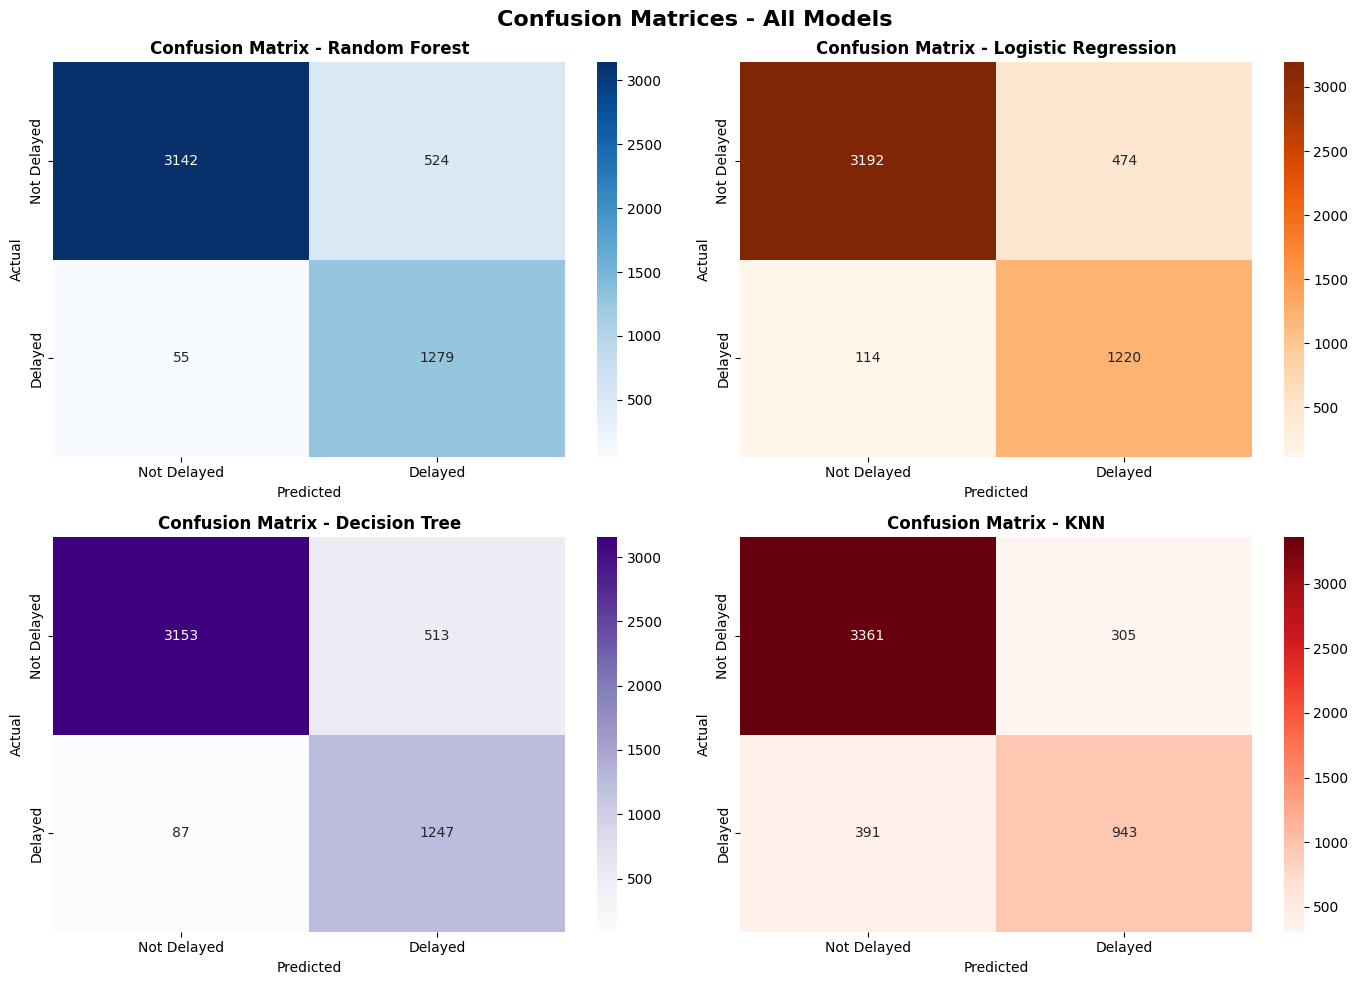

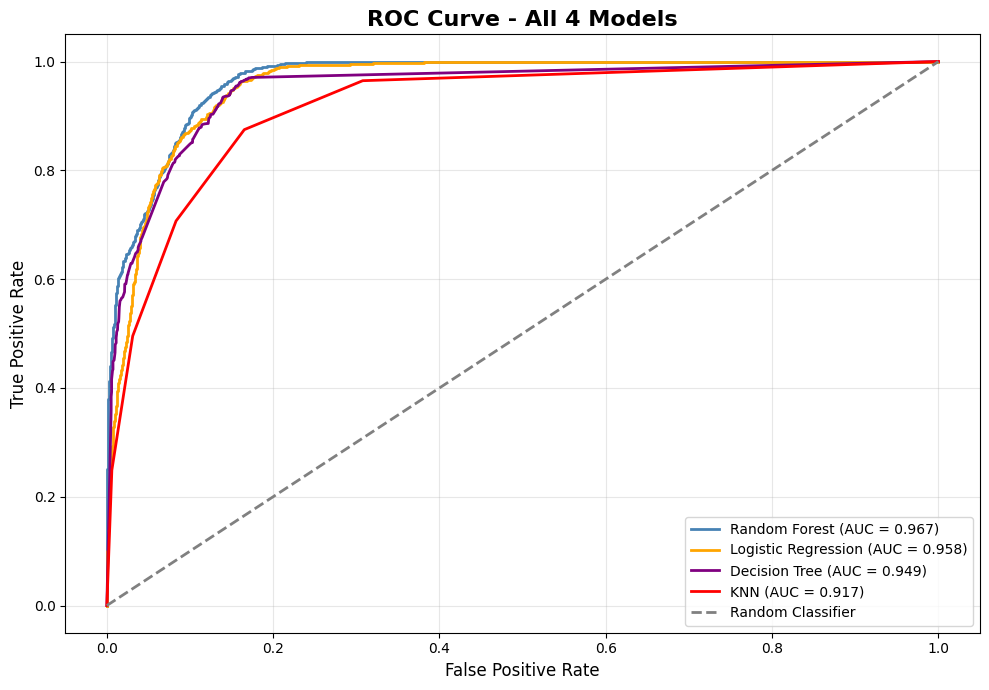

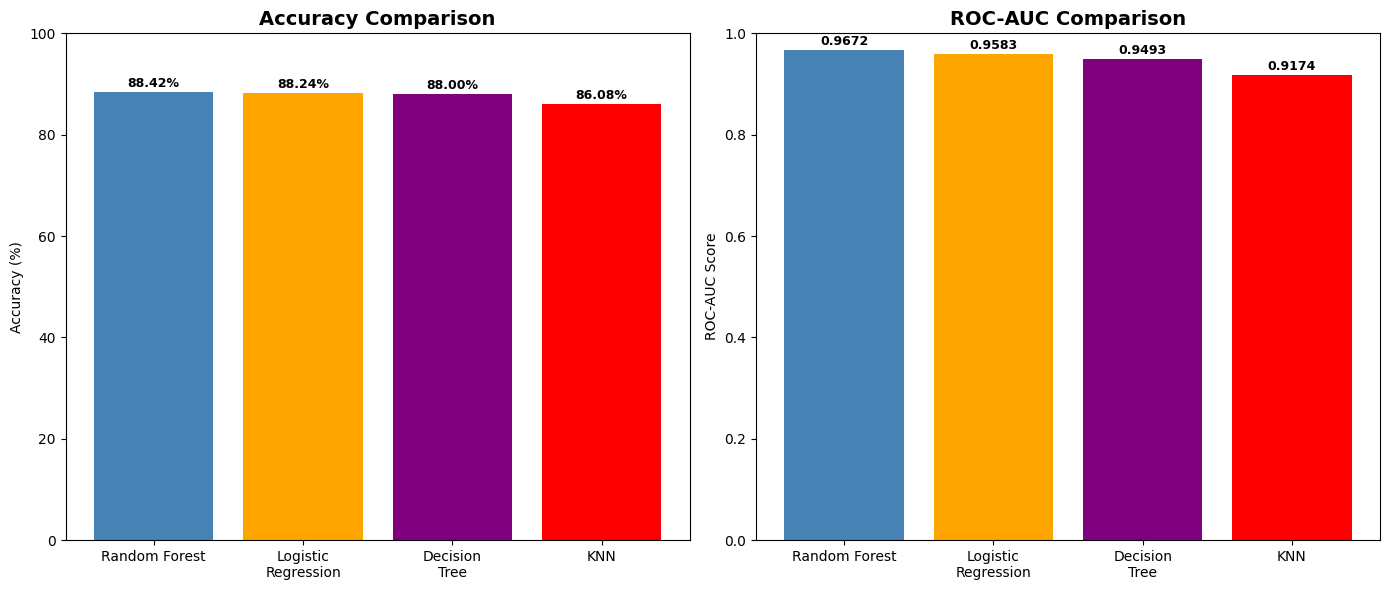

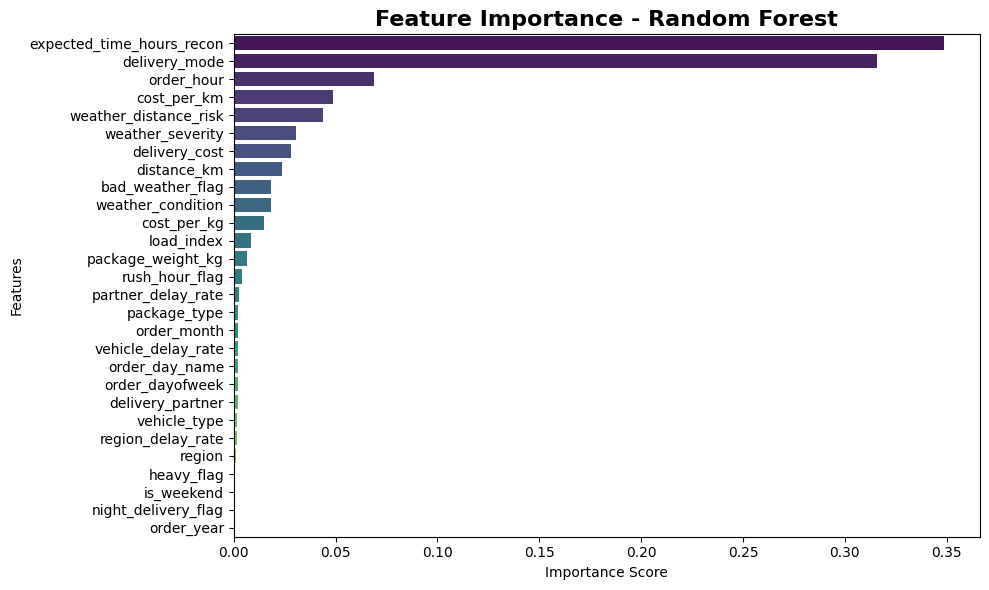


🏆 FINAL MODEL COMPARISON - ALL 4 MODELS
              Model Accuracy (%) ROC-AUC PR-AUC
      Random Forest        88.42  0.9672 0.9131
Logistic Regression        88.24  0.9583 0.8743
      Decision Tree        88.00  0.9493 0.8715
                KNN        86.08  0.9174 0.7714

🥇 Best by Accuracy: Random Forest (88.42%)
🥇 Best by ROC-AUC:  Random Forest (0.9672)

✅ All 4 models saved in models folder!
   - models/rf_delivery_model.pkl
   - models/lr_delivery_model.pkl
   - models/dt_delivery_model.pkl
   - models/knn_delivery_model.pkl
   - models/scaler.pkl
   - models/label_encoders.pkl


In [2]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve,
                              average_precision_score, precision_recall_curve,
                              f1_score, precision_score, recall_score)

# ============================================================
# STEP 1: LOAD DATA
# ============================================================
df = pd.read_csv("../Data/eta_feature_engineered_dataset.csv")
print(f"✅ Dataset loaded! Shape: {df.shape}")

# ============================================================
# STEP 2: SELECT SAFE FEATURES (No Data Leakage)
# ============================================================
# Only use features that would be KNOWN at the time of order placement.
# Dropped: actual delivery times, delay hours, severity, efficiency,
#          time_ratio, early_flag — all derived from the outcome.
# FIX: Removed speed_category — actual travel speed is only known AFTER delivery.
# NOTE: partner/region/vehicle delay rates are NOT included here — they will be
#       computed on TRAIN only after the split to prevent leakage (Step 4b).

SAFE_FEATURES = [
    'delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode',
    'region', 'weather_condition', 'distance_km', 'package_weight_kg',
    'delivery_cost', 'expected_time_hours_recon', 'order_dayofweek',
    'order_day_name', 'order_month', 'order_year', 'order_hour',
    'is_weekend', 'rush_hour_flag', 'night_delivery_flag',
    'cost_per_km', 'cost_per_kg', 'heavy_flag', 'bad_weather_flag',
    'weather_severity', 'weather_distance_risk', 'load_index',
]

# Filter to columns that exist in dataset
SAFE_FEATURES = [f for f in SAFE_FEATURES if f in df.columns]

X = df[SAFE_FEATURES].copy()
# Convert original 'delayed' yes/no to binary 0/1
df['target'] = (df['delayed'] == 'yes').astype(int)
y = df['target']

print(f"\n✅ Features being used ({len(X.columns)}):")
print(X.columns.tolist())
print(f"\n🎯 Target distribution:")
print(y.value_counts())
print(f"Delay rate: {y.mean()*100:.2f}% (using original delayed column)")

# ============================================================
# STEP 3: ENCODE CATEGORICAL VARIABLES
# ============================================================
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"\n📝 Encoding: {categorical_cols}")

label_encoders = {}
X_encoded = X.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    label_encoders[col] = le

print("✅ Encoding done!")

# ============================================================
# STEP 4: TRAIN-TEST SPLIT (80-20)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n✅ Split done!")
print(f"   Training: {X_train.shape[0]} samples")
print(f"   Testing:  {X_test.shape[0]} samples")

# ============================================================
# STEP 4b: DELAY RATE FEATURES — COMPUTED ON TRAIN ONLY
# ============================================================
# FIX: Previously these were computed on the full dataset before the split
# (feature engineering cells 75-77), causing data leakage — test-set outcomes
# were influencing training features.
# Fix: recompute from training rows only, then map to test.
# ============================================================
global_rate = y_train.mean()

for orig_col, rate_col in [
    ('delivery_partner', 'partner_delay_rate'),
    ('region',           'region_delay_rate'),
    ('vehicle_type',     'vehicle_delay_rate'),
]:
    rate_map = df.loc[y_train.index].groupby(orig_col)['target'].mean()
    X_train[rate_col] = df.loc[y_train.index, orig_col].map(rate_map).fillna(global_rate).values
    X_test[rate_col]  = df.loc[y_test.index,  orig_col].map(rate_map).fillna(global_rate).values

print(f"\n✅ Delay rate features added (computed on train only — no leakage)")

# ============================================================
# STEP 5: SCALE FEATURES
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("\n✅ Features scaled!")

# ============================================================
# STEP 6: TRAIN ALL 4 MODELS
# ============================================================

# 1. Random Forest
print("\n🌲 Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_model.fit(X_train_scaled, y_train)
print("✅ Random Forest done!")

# 2. Logistic Regression
print("\n📈 Training Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0,
    class_weight='balanced'
)
lr_model.fit(X_train_scaled, y_train)
print("✅ Logistic Regression done!")

# 3. Decision Tree
print("\n🌳 Training Decision Tree...")
dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    class_weight='balanced'
)
dt_model.fit(X_train_scaled, y_train)
print("✅ Decision Tree done!")

# 4. KNN
print("\n👥 Training KNN...")
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean'
)
knn_model.fit(X_train_scaled, y_train)
print("✅ KNN done!")

# ============================================================
# STEP 7: PREDICTIONS - ALL 4 MODELS
# ============================================================
y_pred_rf  = rf_model.predict(X_test_scaled)
y_pred_lr  = lr_model.predict(X_test_scaled)
y_pred_dt  = dt_model.predict(X_test_scaled)
y_pred_knn = knn_model.predict(X_test_scaled)

y_proba_rf  = rf_model.predict_proba(X_test_scaled)[:, 1]
y_proba_lr  = lr_model.predict_proba(X_test_scaled)[:, 1]
y_proba_dt  = dt_model.predict_proba(X_test_scaled)[:, 1]
y_proba_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

print("\n✅ All predictions done!")

# ============================================================
# STEP 8: EVALUATE ALL 4 MODELS
# ============================================================
rf_acc  = accuracy_score(y_test, y_pred_rf)
lr_acc  = accuracy_score(y_test, y_pred_lr)
dt_acc  = accuracy_score(y_test, y_pred_dt)
knn_acc = accuracy_score(y_test, y_pred_knn)

rf_auc  = roc_auc_score(y_test, y_proba_rf)
lr_auc  = roc_auc_score(y_test, y_proba_lr)
dt_auc  = roc_auc_score(y_test, y_proba_dt)
knn_auc = roc_auc_score(y_test, y_proba_knn)

# PR-AUC (most honest metric for imbalanced data)
rf_prauc  = average_precision_score(y_test, y_proba_rf)
lr_prauc  = average_precision_score(y_test, y_proba_lr)
dt_prauc  = average_precision_score(y_test, y_proba_dt)
knn_prauc = average_precision_score(y_test, y_proba_knn)

print("\n" + "="*60)
print("🌲 RANDOM FOREST")
print("="*60)
print(f"Accuracy: {rf_acc*100:.2f}% | ROC-AUC: {rf_auc:.4f} | PR-AUC: {rf_prauc:.4f}")
print(classification_report(y_test, y_pred_rf, target_names=['Not Delayed', 'Delayed']))

print("="*60)
print("📈 LOGISTIC REGRESSION")
print("="*60)
print(f"Accuracy: {lr_acc*100:.2f}% | ROC-AUC: {lr_auc:.4f} | PR-AUC: {lr_prauc:.4f}")
print(classification_report(y_test, y_pred_lr, target_names=['Not Delayed', 'Delayed']))

print("="*60)
print("🌳 DECISION TREE")
print("="*60)
print(f"Accuracy: {dt_acc*100:.2f}% | ROC-AUC: {dt_auc:.4f} | PR-AUC: {dt_prauc:.4f}")
print(classification_report(y_test, y_pred_dt, target_names=['Not Delayed', 'Delayed']))

print("="*60)
print("👥 KNN")
print("="*60)
print(f"Accuracy: {knn_acc*100:.2f}% | ROC-AUC: {knn_auc:.4f} | PR-AUC: {knn_prauc:.4f}")
print(classification_report(y_test, y_pred_knn, target_names=['Not Delayed', 'Delayed']))

# ============================================================
# STEP 9: CONFUSION MATRICES - ALL 4
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

models_info = [
    (y_pred_rf,  'Random Forest',       'Blues'),
    (y_pred_lr,  'Logistic Regression', 'Oranges'),
    (y_pred_dt,  'Decision Tree',       'Purples'),
    (y_pred_knn, 'KNN',                 'Reds'),
]

for i, (y_pred, title, cmap) in enumerate(models_info):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[i],
                xticklabels=['Not Delayed', 'Delayed'],
                yticklabels=['Not Delayed', 'Delayed'])
    axes[i].set_title(f'Confusion Matrix - {title}', fontweight='bold')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# STEP 10: ROC CURVE - ALL 4 MODELS
# ============================================================
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_proba_rf)
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_proba_lr)
fpr_dt,  tpr_dt,  _ = roc_curve(y_test, y_proba_dt)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)

plt.figure(figsize=(10, 7))
plt.plot(fpr_rf,  tpr_rf,  color='steelblue', lw=2, label=f'Random Forest (AUC = {rf_auc:.3f})')
plt.plot(fpr_lr,  tpr_lr,  color='orange',    lw=2, label=f'Logistic Regression (AUC = {lr_auc:.3f})')
plt.plot(fpr_dt,  tpr_dt,  color='purple',    lw=2, label=f'Decision Tree (AUC = {dt_auc:.3f})')
plt.plot(fpr_knn, tpr_knn, color='red',       lw=2, label=f'KNN (AUC = {knn_auc:.3f})')
plt.plot([0, 1],  [0, 1],  color='gray', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - All 4 Models', fontsize=16, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# STEP 11: COMPARISON BAR CHART
# ============================================================
all_models     = ['Random Forest', 'Logistic\nRegression', 'Decision\nTree', 'KNN']
all_accuracies = [rf_acc*100, lr_acc*100, dt_acc*100, knn_acc*100]
all_roc_aucs   = [rf_auc, lr_auc, dt_auc, knn_auc]
all_colors     = ['steelblue', 'orange', 'purple', 'red']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(all_models, all_accuracies, color=all_colors)
axes[0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([0, 100])
for i, v in enumerate(all_accuracies):
    axes[0].text(i, v + 1, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=9)

axes[1].bar(all_models, all_roc_aucs, color=all_colors)
axes[1].set_title('ROC-AUC Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_ylim([0, 1])
for i, v in enumerate(all_roc_aucs):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# ============================================================
# STEP 12: FEATURE IMPORTANCE (RANDOM FOREST)
# ============================================================
feature_importance = pd.DataFrame({
    'feature': list(X_train.columns),
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance - Random Forest', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# ============================================================
# STEP 13: SUMMARY TABLE
# ============================================================
summary = pd.DataFrame({
    'Model':        ['Random Forest', 'Logistic Regression', 'Decision Tree', 'KNN'],
    'Accuracy (%)': [f"{v:.2f}" for v in all_accuracies],
    'ROC-AUC':      [f"{v:.4f}" for v in all_roc_aucs],
    'PR-AUC':       [f"{v:.4f}" for v in [rf_prauc, lr_prauc, dt_prauc, knn_prauc]]
})

print("\n🏆 FINAL MODEL COMPARISON - ALL 4 MODELS")
print("="*50)
print(summary.to_string(index=False))

best_acc_idx = all_accuracies.index(max(all_accuracies))
best_auc_idx = all_roc_aucs.index(max(all_roc_aucs))
print(f"\n🥇 Best by Accuracy: {summary['Model'][best_acc_idx]} ({max(all_accuracies):.2f}%)")
print(f"🥇 Best by ROC-AUC:  {summary['Model'][best_auc_idx]} ({max(all_roc_aucs):.4f})")

# ============================================================
# STEP 14: SAVE ALL MODELS
# ============================================================
import os

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

with open("../models/rf_delivery_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

with open("../models/lr_delivery_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

with open("../models/dt_delivery_model.pkl", "wb") as f:
    pickle.dump(dt_model, f)

with open("../models/knn_delivery_model.pkl", "wb") as f:
    pickle.dump(knn_model, f)

with open("../models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("../models/label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

print("\n✅ All 4 models saved in models folder!")
print("   - models/rf_delivery_model.pkl")
print("   - models/lr_delivery_model.pkl")
print("   - models/dt_delivery_model.pkl")
print("   - models/knn_delivery_model.pkl")
print("   - models/scaler.pkl")
print("   - models/label_encoders.pkl")

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("../Data/eta_feature_engineered_dataset.csv")

# FIX: Removed speed_category — actual travel speed is only known AFTER delivery.
SAFE_FEATURES = [
    'delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode',
    'region', 'weather_condition', 'distance_km', 'package_weight_kg',
    'delivery_cost', 'expected_time_hours_recon', 'order_dayofweek',
    'order_day_name', 'order_month', 'order_year', 'order_hour',
    'is_weekend', 'rush_hour_flag', 'night_delivery_flag',
    'cost_per_km', 'cost_per_kg', 'heavy_flag', 'bad_weather_flag',
    'weather_severity', 'weather_distance_risk', 'load_index',
]

def encode_features(X):
    X_enc = X.copy()
    encoders = {}
    cat_cols = X_enc.select_dtypes(include=['object', 'category']).columns.tolist()
    for col in cat_cols:
        le = LabelEncoder()
        X_enc[col] = le.fit_transform(X_enc[col].astype(str))
        encoders[col] = le
    return X_enc, encoders

# Model A — Binary Classification (original 'delayed' column yes/no → 1/0)
df['target'] = (df['delayed'] == 'yes').astype(int)
X_A, y_A = df[SAFE_FEATURES].copy(), df['target'].copy()
X_A_enc, encoders_A = encode_features(X_A)

# Model B — Multi-class using delivery_status (delivered / delayed / failed)
# Using original delivery_status column — no reconstructed columns
X_B, y_B = df[SAFE_FEATURES].copy(), df['delivery_status'].copy()
X_B_enc, encoders_B = encode_features(X_B)

print(f"Model A: {X_A_enc.shape}, target distribution:")
print(y_A.value_counts())
print(f"\nDelay rate: {y_A.mean()*100:.2f}%")
print(f"\nModel B: {X_B_enc.shape}, target distribution:")
print(y_B.value_counts())


Model A: (25000, 25), target distribution:
target
0    18331
1     6669
Name: count, dtype: int64

Delay rate: 26.68%

Model B: (25000, 25), target distribution:
delivery_status
delivered    18331
delayed       5341
failed        1328
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Model A — Binary (stratified)
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A_enc, y_A, test_size=0.2, random_state=42, stratify=y_A
)

# Model B — Multi-class (stratified)
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B_enc, y_B, test_size=0.2, random_state=42, stratify=y_B
)

# ============================================================
# FIX: DELAY RATE FEATURES — COMPUTED ON TRAIN ONLY
# ============================================================
# Recompute partner/region/vehicle delay rates using training rows only.
# This prevents test-set outcome information from leaking into features.
# ============================================================
global_rate = y_train_A.mean()

for orig_col, rate_col in [
    ('delivery_partner', 'partner_delay_rate'),
    ('region',           'region_delay_rate'),
    ('vehicle_type',     'vehicle_delay_rate'),
]:
    rate_map = df.loc[y_train_A.index].groupby(orig_col)['target'].mean()
    X_train_A[rate_col] = df.loc[y_train_A.index, orig_col].map(rate_map).fillna(global_rate).values
    X_test_A[rate_col]  = df.loc[y_test_A.index,  orig_col].map(rate_map).fillna(global_rate).values
    X_train_B[rate_col] = df.loc[y_train_B.index, orig_col].map(rate_map).fillna(global_rate).values
    X_test_B[rate_col]  = df.loc[y_test_B.index,  orig_col].map(rate_map).fillna(global_rate).values

print("✅ Delay rate features added (computed on train only — no leakage)")

scaler_A = StandardScaler()
X_train_A_sc = scaler_A.fit_transform(X_train_A)
X_test_A_sc  = scaler_A.transform(X_test_A)

scaler_B = StandardScaler()
X_train_B_sc = scaler_B.fit_transform(X_train_B)
X_test_B_sc  = scaler_B.transform(X_test_B)

print(f"A → Train: {len(X_train_A)}, Test: {len(X_test_A)}, Delay rate: {y_train_A.mean()*100:.2f}%")
print(f"B → Train: {len(X_train_B)}, Test: {len(X_test_B)}")
print(f"B class distribution in train:\n{y_train_B.value_counts()}")


✅ Delay rate features added (computed on train only — no leakage)
A → Train: 20000, Test: 5000, Delay rate: 26.67%
B → Train: 20000, Test: 5000
B class distribution in train:
delivery_status
delivered    14665
delayed       4273
failed        1062
Name: count, dtype: int64


In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report,
                              average_precision_score, f1_score)

# ── Model A: Binary (delayed vs on-time) ──────────────────────────────────
dummy_A = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_A.fit(X_train_A_sc, y_train_A)
print("Dummy A Accuracy:", accuracy_score(y_test_A, dummy_A.predict(X_test_A_sc)))
print("Dummy A AUC:     ", roc_auc_score(y_test_A, dummy_A.predict_proba(X_test_A_sc)[:,1]))

lr_A = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_A.fit(X_train_A_sc, y_train_A)
y_pred_lr_A  = lr_A.predict(X_test_A_sc)
y_proba_lr_A = lr_A.predict_proba(X_test_A_sc)[:,1]
print("\nLR-A Accuracy:", accuracy_score(y_test_A, y_pred_lr_A))
print("LR-A AUC:     ", roc_auc_score(y_test_A, y_proba_lr_A))
print("LR-A PR-AUC:  ", average_precision_score(y_test_A, y_proba_lr_A))
print(classification_report(y_test_A, y_pred_lr_A, target_names=['On-Time', 'Delayed']))

# ── Model B: Multi-class (delivered / delayed / failed) ───────────────────
dummy_B = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_B.fit(X_train_B_sc, y_train_B)
print("Dummy B Accuracy:", accuracy_score(y_test_B, dummy_B.predict(X_test_B_sc)))

lr_B = LogisticRegression(max_iter=2000, random_state=42,
                           class_weight='balanced')
lr_B.fit(X_train_B_sc, y_train_B)
y_pred_lr_B = lr_B.predict(X_test_B_sc)
print("\nLR-B Accuracy:", accuracy_score(y_test_B, y_pred_lr_B))
print(classification_report(y_test_B, y_pred_lr_B))

Dummy A Accuracy: 0.7332
Dummy A AUC:      0.5

LR-A Accuracy: 0.8824
LR-A AUC:      0.958294788775825
LR-A PR-AUC:   0.8743170009463117
              precision    recall  f1-score   support

     On-Time       0.97      0.87      0.92      3666
     Delayed       0.72      0.91      0.81      1334

    accuracy                           0.88      5000
   macro avg       0.84      0.89      0.86      5000
weighted avg       0.90      0.88      0.89      5000

Dummy B Accuracy: 0.7332

LR-B Accuracy: 0.775
              precision    recall  f1-score   support

     delayed       0.60      0.49      0.54      1068
   delivered       0.97      0.88      0.92      3666
      failed       0.15      0.45      0.22       266

    accuracy                           0.78      5000
   macro avg       0.57      0.61      0.56      5000
weighted avg       0.85      0.78      0.81      5000



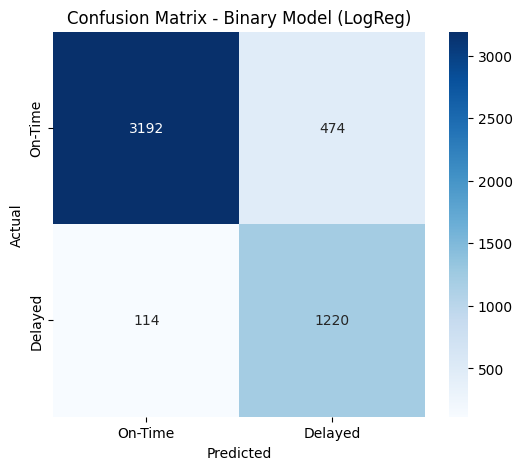

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_A = confusion_matrix(y_test_A, y_pred_lr_A)

plt.figure(figsize=(6,5))
sns.heatmap(cm_A, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On-Time','Delayed'],
            yticklabels=['On-Time','Delayed'])
plt.title("Confusion Matrix - Binary Model (LogReg)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

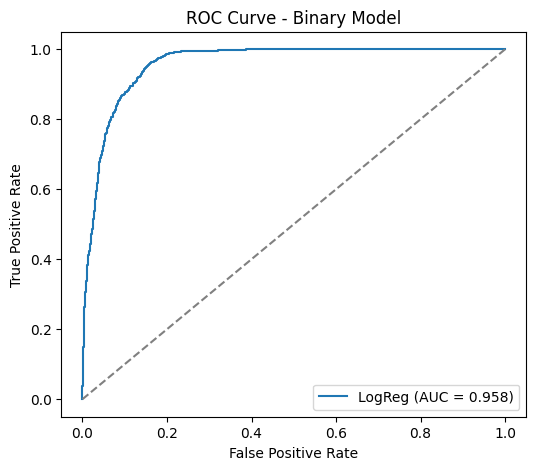

In [7]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test_A, y_proba_lr_A)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="LogReg (AUC = %.3f)" % roc_auc_score(y_test_A, y_proba_lr_A))
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Binary Model")
plt.legend()
plt.show()

In [8]:
# Residual plot removed — Model C (regression on delay_hours_recon) 
# has been replaced with Model B using original delivery_status column.
# See Model B confusion matrices and evaluation below.
print("Model C (regression) removed. Using original delivery_status for Model B.")

Model C (regression) removed. Using original delivery_status for Model B.


In [9]:
from sklearn.model_selection import cross_val_score

cv_scores_auc = cross_val_score(
    lr_A,
    X_A_enc,
    y_A,
    cv=5,
    scoring='roc_auc'
)

print("Cross-Validated AUC Scores:", cv_scores_auc)
print("Mean CV AUC:", cv_scores_auc.mean())
print("Std Dev CV AUC:", cv_scores_auc.std())

Cross-Validated AUC Scores: [0.95654968 0.95893911 0.95954171 0.95309649 0.95675751]
Mean CV AUC: 0.9569768974104317
Std Dev CV AUC: 0.00226789589700579


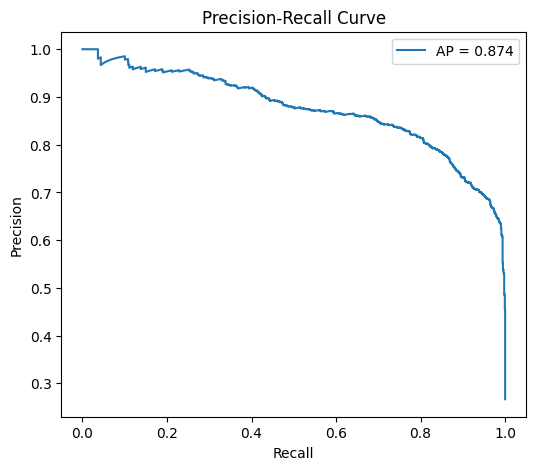

In [10]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test_A, y_proba_lr_A)
ap_score = average_precision_score(y_test_A, y_proba_lr_A)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"AP = {ap_score:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [11]:
custom_threshold = 0.6

y_pred_custom = (y_proba_lr_A >= custom_threshold).astype(int)

print("Custom Threshold Accuracy:",
      accuracy_score(y_test_A, y_pred_custom))

Custom Threshold Accuracy: 0.8932


In [12]:
# Error distribution plot removed (was for regression Model C).
# Model B now predicts delivery_status: delivered / delayed / failed
print("Skipped — regression model removed.")

Skipped — regression model removed.


In [13]:
# Adjusted R² removed (was for regression Model C).
print("Skipped — regression model removed.")

Skipped — regression model removed.


FEATURE IMPORTANCE

In [14]:
coef_df = pd.DataFrame({
    "Feature": list(X_train.columns),
    "Coefficient": lr_A.coef_[0]
})

coef_df["Abs_Coefficient"] = np.abs(coef_df["Coefficient"])
coef_df = coef_df.sort_values(by="Abs_Coefficient", ascending=False)

coef_df.head(10)

,Feature,Coefficient,Abs_Coefficient
8,delivery_cost,3.001454,3.001454
9,expected_time_hours_recon,-2.696871,2.696871
6,distance_km,-1.828539,1.828539
21,bad_weather_flag,0.937207,0.937207
3,delivery_mode,-0.937034,0.937034
12,order_month,-0.789705,0.789705
4,region,0.771222,0.771222
5,weather_condition,0.410233,0.410233
7,package_weight_kg,-0.389086,0.389086
23,weather_distance_risk,0.313965,0.313965


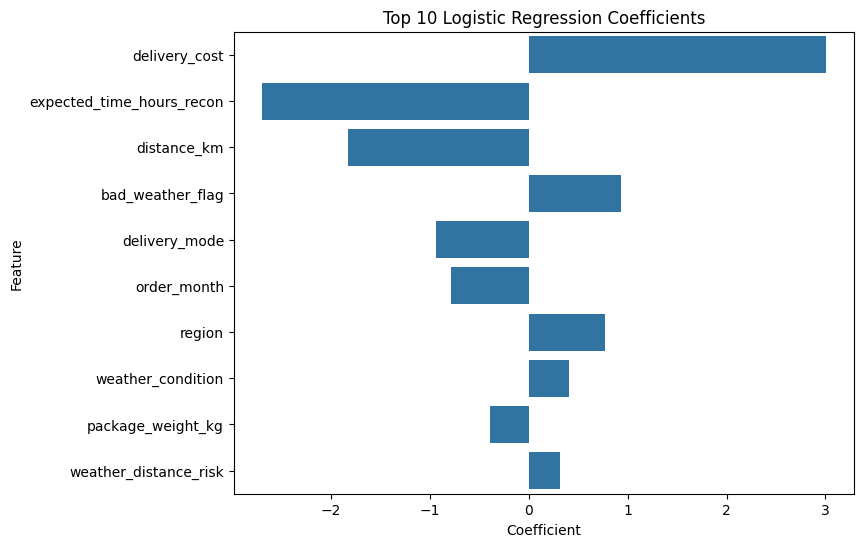

In [15]:
plt.figure(figsize=(8,6))
sns.barplot(data=coef_df.head(10),
            x="Coefficient",
            y="Feature")
plt.title("Top 10 Logistic Regression Coefficients")
plt.show()

In [16]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    lr_A,
    X_test_A_sc,
    y_test_A,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc'
)

perm_df = pd.DataFrame({
    "Feature": list(X_train.columns),
    "Importance": perm.importances_mean
}).sort_values(by="Importance", ascending=False)

perm_df.head(10)

,Feature,Importance
9,expected_time_hours_recon,0.234352
8,delivery_cost,0.160088
6,distance_km,0.048928
21,bad_weather_flag,0.026097
3,delivery_mode,0.014015
12,order_month,0.013815
4,region,0.010159
5,weather_condition,0.005321
7,package_weight_kg,0.003334
23,weather_distance_risk,0.002882


🥇 Most Influential Feature:
expected_time_hours_recon

Coefficient ≈ -7.36

This is HUGE compared to others.

What it means:

As expected delivery time increases,
probability of delay decreases (negative coefficient).

This might seem counterintuitive at first.

But think logically:

If expected time is already long,
the system has built-in buffer.

Short expected times are harder to meet,
so delay probability increases.

That’s operational logic.

🥈 delivery_mode

Strong negative coefficient (~ -4.8)

Certain delivery modes likely reduce delay probability.
For example:

Express vs same-day might behave differently.

🥉 distance_km

Positive coefficient (~ +3.15)

This means:

Longer distance → higher probability of delay.

That makes intuitive sense.

Other Important Drivers

vehicle_type

delivery_cost

weather_severity

bad_weather_flag

Weather and operational features are clearly influential.

This aligns with your earlier regression model insights.

🔹 What Permutation Importance Tells You

Permutation importance measures:

How much model performance drops if we shuffle that feature.

It is more reliable than raw coefficients.

Top 3:

expected_time_hours_recon

delivery_mode

distance_km

Same pattern as coefficients.

This consistency = strong model stability.

PART 9 — FEATURE SELECTION

In [17]:
top_features = perm_df.head(10)["Feature"].tolist()
print("Selected Features:", top_features)

Selected Features: ['expected_time_hours_recon', 'delivery_cost', 'distance_km', 'bad_weather_flag', 'delivery_mode', 'order_month', 'region', 'weather_condition', 'package_weight_kg', 'weather_distance_risk']


In [18]:
X_train_sel = X_train_A[top_features]
X_test_sel  = X_test_A[top_features]

scaler_sel = StandardScaler()
X_train_sel_sc = scaler_sel.fit_transform(X_train_sel)
X_test_sel_sc  = scaler_sel.transform(X_test_sel)

lr_sel = LogisticRegression(max_iter=1000, random_state=42)
lr_sel.fit(X_train_sel_sc, y_train_A)

y_pred_sel = lr_sel.predict(X_test_sel_sc)
y_proba_sel = lr_sel.predict_proba(X_test_sel_sc)[:,1]

print("Selected Model AUC:",
      roc_auc_score(y_test_A, y_proba_sel))

Selected Model AUC: 0.9593284372543678


In [19]:
from sklearn.feature_selection import RFE

rfe = RFE(lr_A, n_features_to_select=10)
rfe.fit(X_train_A_sc, y_train_A)

selected_rfe = [SAFE_FEATURES[i]
                for i in range(len(SAFE_FEATURES))
                if rfe.support_[i]]

print("RFE Selected Features:", selected_rfe)

RFE Selected Features: ['delivery_mode', 'weather_condition', 'distance_km', 'package_weight_kg', 'delivery_cost', 'expected_time_hours_recon', 'order_month', 'bad_weather_flag', 'weather_severity', 'weather_distance_risk']


# PART 10 — MODEL BUILDING: ALL 4 CLASSIFICATION MODELS
## (Model A — Binary | Model B — Multi-class)

## MODEL A — BINARY CLASSIFICATION (Delayed vs On-Time)
### All 4 Classifiers: Random Forest | Logistic Regression | Decision Tree | KNN

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve,
                              f1_score, precision_score, recall_score)
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# ============================================================
# STEP 1 — TRAIN ALL 4 CLASSIFIERS (Model A: Binary)
# ============================================================

# 1. Random Forest
print("\n🌲 Training Random Forest...")
rf_A = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_A.fit(X_train_A_sc, y_train_A)
print("✅ Random Forest done!")

# 2. Logistic Regression
print("\n📈 Training Logistic Regression...")
lr_A2 = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0,
    class_weight='balanced'
)
lr_A2.fit(X_train_A_sc, y_train_A)
print("✅ Logistic Regression done!")

# 3. Decision Tree
print("\n🌳 Training Decision Tree...")
dt_A = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    class_weight='balanced'
)
dt_A.fit(X_train_A_sc, y_train_A)
print("✅ Decision Tree done!")

# 4. KNN
print("\n👥 Training KNN...")
knn_A = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean'
)
knn_A.fit(X_train_A_sc, y_train_A)
print("✅ KNN done!")



🌲 Training Random Forest...


✅ Random Forest done!

📈 Training Logistic Regression...
✅ Logistic Regression done!

🌳 Training Decision Tree...
✅ Decision Tree done!

👥 Training KNN...
✅ KNN done!


In [21]:
# ============================================================
# STEP 2 — PREDICTIONS: ALL 4 MODELS (Model A)
# ============================================================

y_pred_rf_A   = rf_A.predict(X_test_A_sc)
y_pred_lr_A2  = lr_A2.predict(X_test_A_sc)
y_pred_dt_A   = dt_A.predict(X_test_A_sc)
y_pred_knn_A  = knn_A.predict(X_test_A_sc)

y_proba_rf_A   = rf_A.predict_proba(X_test_A_sc)[:, 1]
y_proba_lr_A2  = lr_A2.predict_proba(X_test_A_sc)[:, 1]
y_proba_dt_A   = dt_A.predict_proba(X_test_A_sc)[:, 1]
y_proba_knn_A  = knn_A.predict_proba(X_test_A_sc)[:, 1]

print("✅ All predictions done!")


✅ All predictions done!


In [22]:
# ============================================================
# STEP 3 — EVALUATE ALL 4 MODELS (Model A)
# ============================================================

rf_acc_A   = accuracy_score(y_test_A, y_pred_rf_A)
lr_acc_A2  = accuracy_score(y_test_A, y_pred_lr_A2)
dt_acc_A   = accuracy_score(y_test_A, y_pred_dt_A)
knn_acc_A  = accuracy_score(y_test_A, y_pred_knn_A)

rf_auc_A   = roc_auc_score(y_test_A, y_proba_rf_A)
lr_auc_A2  = roc_auc_score(y_test_A, y_proba_lr_A2)
dt_auc_A   = roc_auc_score(y_test_A, y_proba_dt_A)
knn_auc_A  = roc_auc_score(y_test_A, y_proba_knn_A)

# PR-AUC
rf_prauc_A   = average_precision_score(y_test_A, y_proba_rf_A)
lr_prauc_A2  = average_precision_score(y_test_A, y_proba_lr_A2)
dt_prauc_A   = average_precision_score(y_test_A, y_proba_dt_A)
knn_prauc_A  = average_precision_score(y_test_A, y_proba_knn_A)

print("=" * 60)
print("🌲 RANDOM FOREST — Model A")
print("=" * 60)
print(f"Accuracy : {rf_acc_A*100:.2f}% | ROC-AUC: {rf_auc_A:.4f} | PR-AUC: {rf_prauc_A:.4f}")
print(f"F1-Score : {f1_score(y_test_A, y_pred_rf_A):.4f} | Precision: {precision_score(y_test_A, y_pred_rf_A):.4f} | Recall: {recall_score(y_test_A, y_pred_rf_A):.4f}")
print(classification_report(y_test_A, y_pred_rf_A, target_names=['On-Time', 'Delayed']))

print("=" * 60)
print("📈 LOGISTIC REGRESSION — Model A")
print("=" * 60)
print(f"Accuracy : {lr_acc_A2*100:.2f}% | ROC-AUC: {lr_auc_A2:.4f} | PR-AUC: {lr_prauc_A2:.4f}")
print(f"F1-Score : {f1_score(y_test_A, y_pred_lr_A2):.4f} | Precision: {precision_score(y_test_A, y_pred_lr_A2):.4f} | Recall: {recall_score(y_test_A, y_pred_lr_A2):.4f}")
print(classification_report(y_test_A, y_pred_lr_A2, target_names=['On-Time', 'Delayed']))

print("=" * 60)
print("🌳 DECISION TREE — Model A")
print("=" * 60)
print(f"Accuracy : {dt_acc_A*100:.2f}% | ROC-AUC: {dt_auc_A:.4f} | PR-AUC: {dt_prauc_A:.4f}")
print(f"F1-Score : {f1_score(y_test_A, y_pred_dt_A):.4f} | Precision: {precision_score(y_test_A, y_pred_dt_A):.4f} | Recall: {recall_score(y_test_A, y_pred_dt_A):.4f}")
print(classification_report(y_test_A, y_pred_dt_A, target_names=['On-Time', 'Delayed']))

print("=" * 60)
print("👥 KNN — Model A")
print("=" * 60)
print(f"Accuracy : {knn_acc_A*100:.2f}% | ROC-AUC: {knn_auc_A:.4f} | PR-AUC: {knn_prauc_A:.4f}")
print(f"F1-Score : {f1_score(y_test_A, y_pred_knn_A):.4f} | Precision: {precision_score(y_test_A, y_pred_knn_A):.4f} | Recall: {recall_score(y_test_A, y_pred_knn_A):.4f}")
print(classification_report(y_test_A, y_pred_knn_A, target_names=['On-Time', 'Delayed']))


🌲 RANDOM FOREST — Model A
Accuracy : 88.42% | ROC-AUC: 0.9672 | PR-AUC: 0.9131
F1-Score : 0.8154 | Precision: 0.7094 | Recall: 0.9588
              precision    recall  f1-score   support

     On-Time       0.98      0.86      0.92      3666
     Delayed       0.71      0.96      0.82      1334

    accuracy                           0.88      5000
   macro avg       0.85      0.91      0.87      5000
weighted avg       0.91      0.88      0.89      5000

📈 LOGISTIC REGRESSION — Model A
Accuracy : 88.24% | ROC-AUC: 0.9583 | PR-AUC: 0.8743
F1-Score : 0.8058 | Precision: 0.7202 | Recall: 0.9145
              precision    recall  f1-score   support

     On-Time       0.97      0.87      0.92      3666
     Delayed       0.72      0.91      0.81      1334

    accuracy                           0.88      5000
   macro avg       0.84      0.89      0.86      5000
weighted avg       0.90      0.88      0.89      5000

🌳 DECISION TREE — Model A
Accuracy : 88.00% | ROC-AUC: 0.9493 | PR-AUC: 

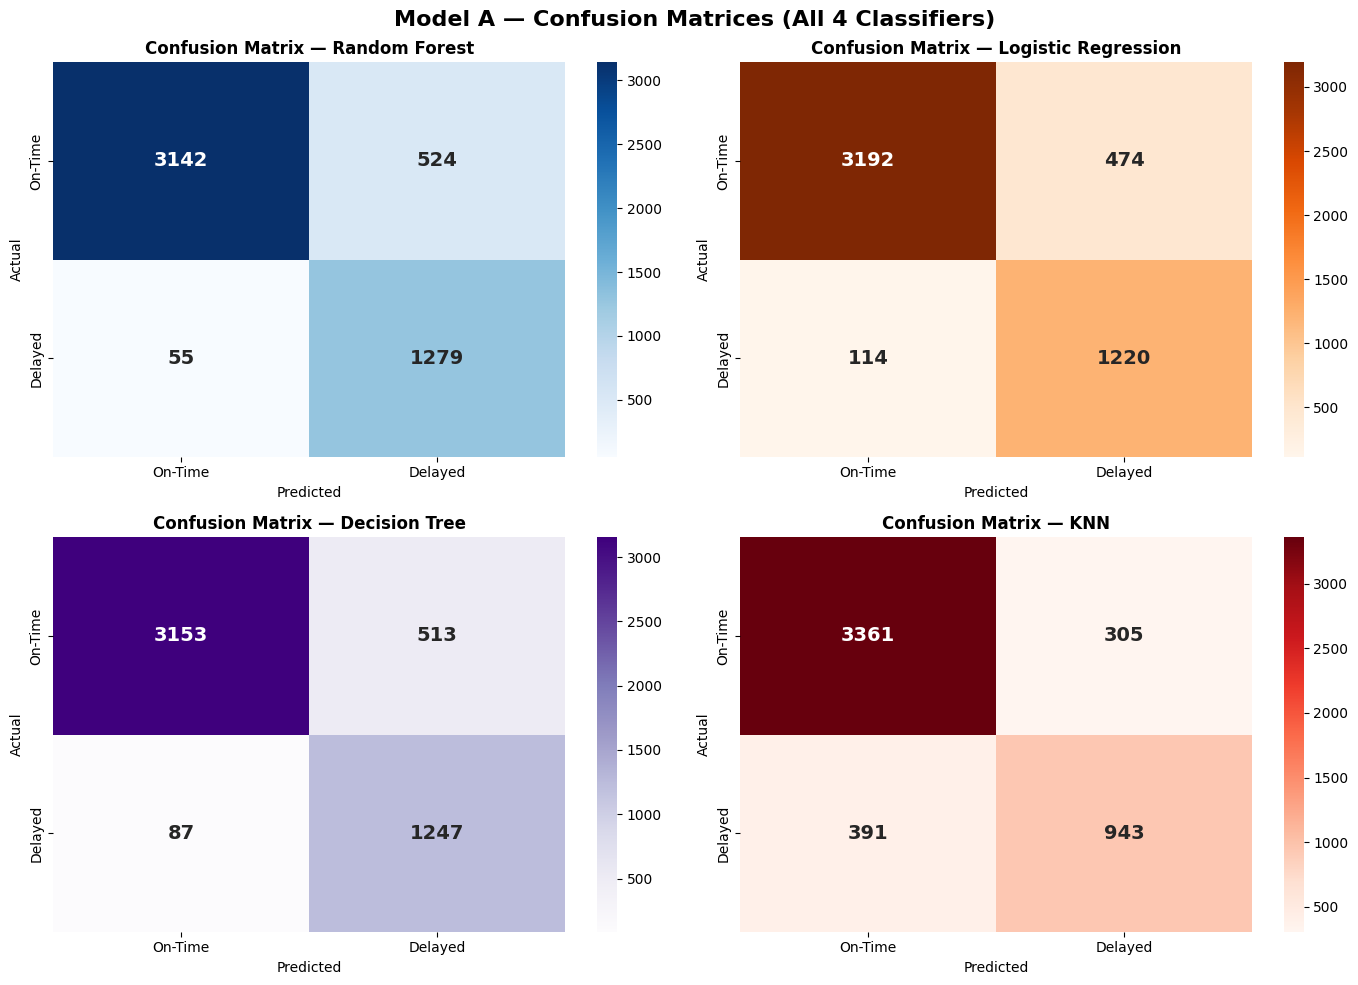

In [23]:
# ============================================================
# STEP 4 — CONFUSION MATRICES: ALL 4 MODELS (Model A)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

models_A_info = [
    (y_pred_rf_A,  'Random Forest',       'Blues'),
    (y_pred_lr_A2, 'Logistic Regression', 'Oranges'),
    (y_pred_dt_A,  'Decision Tree',       'Purples'),
    (y_pred_knn_A, 'KNN',                 'Reds'),
]

for i, (y_pred, title, cmap) in enumerate(models_A_info):
    cm = confusion_matrix(y_test_A, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[i],
                xticklabels=['On-Time', 'Delayed'],
                yticklabels=['On-Time', 'Delayed'],
                annot_kws={'size': 14, 'weight': 'bold'})
    axes[i].set_title(f'Confusion Matrix — {title}', fontweight='bold', fontsize=12)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.suptitle('Model A — Confusion Matrices (All 4 Classifiers)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


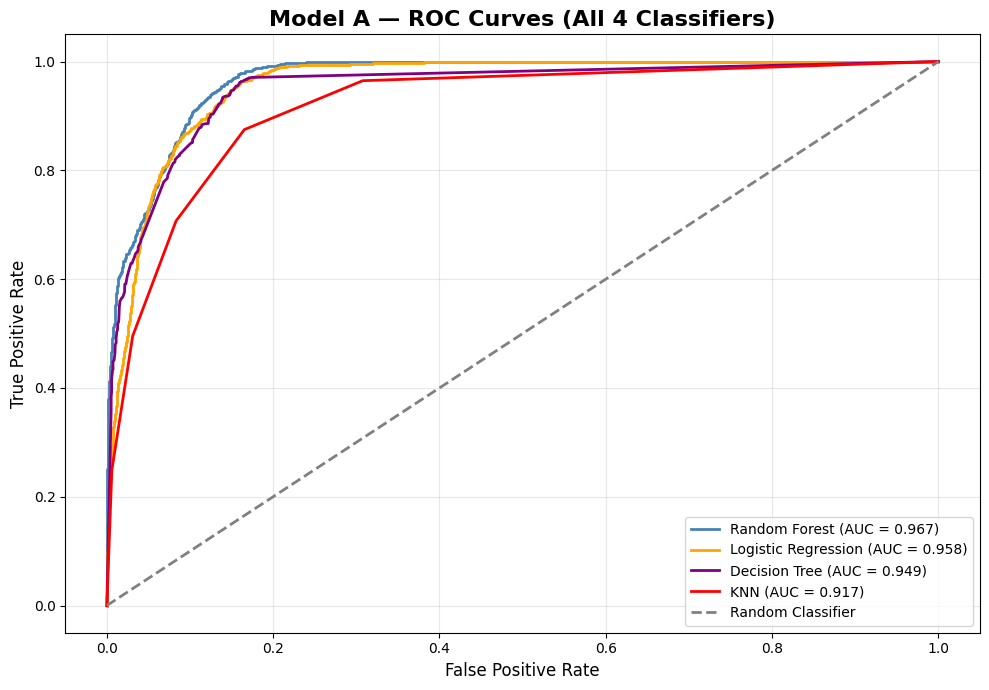

In [24]:
# ============================================================
# STEP 5 — ROC CURVES: ALL 4 MODELS (Model A)
# ============================================================

fpr_rf_A,   tpr_rf_A,   _ = roc_curve(y_test_A, y_proba_rf_A)
fpr_lr_A2,  tpr_lr_A2,  _ = roc_curve(y_test_A, y_proba_lr_A2)
fpr_dt_A,   tpr_dt_A,   _ = roc_curve(y_test_A, y_proba_dt_A)
fpr_knn_A,  tpr_knn_A,  _ = roc_curve(y_test_A, y_proba_knn_A)

plt.figure(figsize=(10, 7))
plt.plot(fpr_rf_A,  tpr_rf_A,  color='steelblue', lw=2, label=f'Random Forest (AUC = {rf_auc_A:.3f})')
plt.plot(fpr_lr_A2, tpr_lr_A2, color='orange',    lw=2, label=f'Logistic Regression (AUC = {lr_auc_A2:.3f})')
plt.plot(fpr_dt_A,  tpr_dt_A,  color='purple',    lw=2, label=f'Decision Tree (AUC = {dt_auc_A:.3f})')
plt.plot(fpr_knn_A, tpr_knn_A, color='red',       lw=2, label=f'KNN (AUC = {knn_auc_A:.3f})')
plt.plot([0, 1],    [0, 1],    color='gray', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Model A — ROC Curves (All 4 Classifiers)', fontsize=16, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


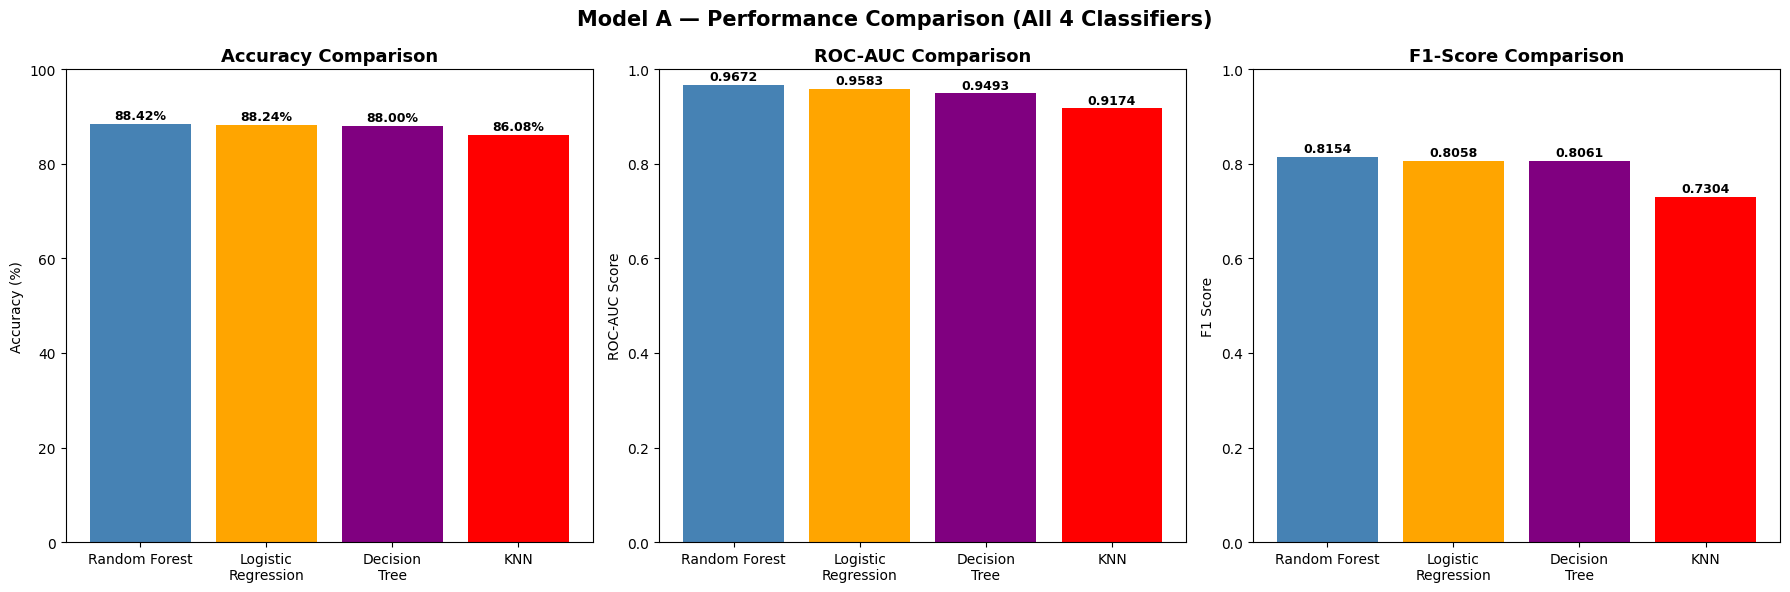

In [25]:
# ============================================================
# STEP 6 — ACCURACY & ROC-AUC BAR CHART (Model A)
# ============================================================

all_models_A     = ['Random Forest', 'Logistic\nRegression', 'Decision\nTree', 'KNN']
all_accuracies_A = [rf_acc_A*100, lr_acc_A2*100, dt_acc_A*100, knn_acc_A*100]
all_roc_aucs_A   = [rf_auc_A, lr_auc_A2, dt_auc_A, knn_auc_A]
all_f1s_A        = [f1_score(y_test_A, y_pred_rf_A),
                    f1_score(y_test_A, y_pred_lr_A2),
                    f1_score(y_test_A, y_pred_dt_A),
                    f1_score(y_test_A, y_pred_knn_A)]
all_prauc_A      = [rf_prauc_A, lr_prauc_A2, dt_prauc_A, knn_prauc_A]
all_colors_A     = ['steelblue', 'orange', 'purple', 'red']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Accuracy
axes[0].bar(all_models_A, all_accuracies_A, color=all_colors_A)
axes[0].set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([0, 100])
for i, v in enumerate(all_accuracies_A):
    axes[0].text(i, v + 1, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=9)

# ROC-AUC
axes[1].bar(all_models_A, all_roc_aucs_A, color=all_colors_A)
axes[1].set_title('ROC-AUC Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_ylim([0, 1])
for i, v in enumerate(all_roc_aucs_A):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

# F1
axes[2].bar(all_models_A, all_f1s_A, color=all_colors_A)
axes[2].set_title('F1-Score Comparison', fontsize=13, fontweight='bold')
axes[2].set_ylabel('F1 Score')
axes[2].set_ylim([0, 1])
for i, v in enumerate(all_f1s_A):
    axes[2].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Model A — Performance Comparison (All 4 Classifiers)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [26]:
# ============================================================
# STEP 8 — SUMMARY TABLE (Model A)
# ============================================================

summary_A = pd.DataFrame({
    'Model':        ['Random Forest', 'Logistic Regression', 'Decision Tree', 'KNN'],
    'Accuracy (%)': [f"{v:.2f}" for v in all_accuracies_A],
    'ROC-AUC':      [f"{v:.4f}" for v in all_roc_aucs_A],
    'F1-Score':     [f"{v:.4f}" for v in all_f1s_A],
    'PR-AUC':       [f"{v:.4f}" for v in all_prauc_A],
})

print("\n🏆 MODEL A — FINAL COMPARISON (All 4 Classifiers)")
print("=" * 65)
print(summary_A.to_string(index=False))

best_acc_idx_A = all_accuracies_A.index(max(all_accuracies_A))
best_auc_idx_A = all_roc_aucs_A.index(max(all_roc_aucs_A))
best_f1_idx_A  = all_f1s_A.index(max(all_f1s_A))

print(f"\n🥇 Best by Accuracy : {summary_A['Model'][best_acc_idx_A]} ({max(all_accuracies_A):.2f}%)")
print(f"🥇 Best by ROC-AUC  : {summary_A['Model'][best_auc_idx_A]} ({max(all_roc_aucs_A):.4f})")
print(f"🥇 Best by F1-Score : {summary_A['Model'][best_f1_idx_A]} ({max(all_f1s_A):.4f})")



🏆 MODEL A — FINAL COMPARISON (All 4 Classifiers)
              Model Accuracy (%) ROC-AUC F1-Score PR-AUC
      Random Forest        88.42  0.9672   0.8154 0.9131
Logistic Regression        88.24  0.9583   0.8058 0.8743
      Decision Tree        88.00  0.9493   0.8061 0.8715
                KNN        86.08  0.9174   0.7304 0.7714

🥇 Best by Accuracy : Random Forest (88.42%)
🥇 Best by ROC-AUC  : Random Forest (0.9672)
🥇 Best by F1-Score : Random Forest (0.8154)


## MODEL B — MULTI-CLASS CLASSIFICATION (Delivery Status: delivered / delayed / failed)
### Using original delivery_status column — All 4 Classifiers: Random Forest | Logistic Regression | Decision Tree | KNN

In [27]:
# ============================================================
# STEP 9 — TRAIN ALL 4 CLASSIFIERS (Model B: Multi-class)
# ============================================================

from sklearn.metrics import f1_score as f1

print(f"Model B Target: delivery_status (original column)")
print(f"Classes: {sorted(y_B.unique())}")
print(f"Class distribution:\n{y_B.value_counts()}\n")

# 1. Random Forest
print("🌲 Training Random Forest (Model B)...")
rf_B = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_B.fit(X_train_B_sc, y_train_B)
print("✅ Random Forest done!")

# 2. Logistic Regression
print("\n📈 Training Logistic Regression (Model B)...")
lr_B2 = LogisticRegression(
    max_iter=2000,
    random_state=42,
    C=1.0,
    class_weight='balanced'
)
lr_B2.fit(X_train_B_sc, y_train_B)
print("✅ Logistic Regression done!")

# 3. Decision Tree
print("\n🌳 Training Decision Tree (Model B)...")
dt_B = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    class_weight='balanced'
)
dt_B.fit(X_train_B_sc, y_train_B)
print("✅ Decision Tree done!")

# 4. KNN
print("\n👥 Training KNN (Model B)...")
knn_B = KNeighborsClassifier(
    n_neighbors=7,
    metric='euclidean'
)
knn_B.fit(X_train_B_sc, y_train_B)
print("✅ KNN done!")


Model B Target: delivery_status (original column)
Classes: ['delayed', 'delivered', 'failed']
Class distribution:
delivery_status
delivered    18331
delayed       5341
failed        1328
Name: count, dtype: int64

🌲 Training Random Forest (Model B)...
✅ Random Forest done!

📈 Training Logistic Regression (Model B)...
✅ Logistic Regression done!

🌳 Training Decision Tree (Model B)...
✅ Decision Tree done!

👥 Training KNN (Model B)...
✅ KNN done!


In [28]:
# ============================================================
# STEP 10 — PREDICTIONS & EVALUATION (Model B)
# ============================================================

y_pred_rf_B   = rf_B.predict(X_test_B_sc)
y_pred_lr_B2  = lr_B2.predict(X_test_B_sc)
y_pred_dt_B   = dt_B.predict(X_test_B_sc)
y_pred_knn_B  = knn_B.predict(X_test_B_sc)

rf_acc_B   = accuracy_score(y_test_B, y_pred_rf_B)
lr_acc_B2  = accuracy_score(y_test_B, y_pred_lr_B2)
dt_acc_B   = accuracy_score(y_test_B, y_pred_dt_B)
knn_acc_B  = accuracy_score(y_test_B, y_pred_knn_B)

rf_f1_B    = f1(y_test_B, y_pred_rf_B,   average='macro')
lr_f1_B2   = f1(y_test_B, y_pred_lr_B2,  average='macro')
dt_f1_B    = f1(y_test_B, y_pred_dt_B,   average='macro')
knn_f1_B   = f1(y_test_B, y_pred_knn_B,  average='macro')

print("=" * 60)
print(" RANDOM FOREST — Model B (Multi-class)")
print("=" * 60)
print(f"Accuracy: {rf_acc_B*100:.2f}% | F1-macro: {rf_f1_B:.4f}")
print(classification_report(y_test_B, y_pred_rf_B))

print("=" * 60)
print(" LOGISTIC REGRESSION — Model B (Multi-class)")
print("=" * 60)
print(f"Accuracy: {lr_acc_B2*100:.2f}% | F1-macro: {lr_f1_B2:.4f}")
print(classification_report(y_test_B, y_pred_lr_B2))

print("=" * 60)
print(" DECISION TREE — Model B (Multi-class)")
print("=" * 60)
print(f"Accuracy: {dt_acc_B*100:.2f}% | F1-macro: {dt_f1_B:.4f}")
print(classification_report(y_test_B, y_pred_dt_B))

print("=" * 60)
print(" KNN — Model B (Multi-class)")
print("=" * 60)
print(f"Accuracy: {knn_acc_B*100:.2f}% | F1-macro: {knn_f1_B:.4f}")
print(classification_report(y_test_B, y_pred_knn_B))


 RANDOM FOREST — Model B (Multi-class)
Accuracy: 81.68% | F1-macro: 0.5922
              precision    recall  f1-score   support

     delayed       0.58      0.84      0.68      1068
   delivered       0.99      0.86      0.92      3666
      failed       0.18      0.18      0.18       266

    accuracy                           0.82      5000
   macro avg       0.58      0.62      0.59      5000
weighted avg       0.86      0.82      0.83      5000

 LOGISTIC REGRESSION — Model B (Multi-class)
Accuracy: 77.50% | F1-macro: 0.5630
              precision    recall  f1-score   support

     delayed       0.60      0.49      0.54      1068
   delivered       0.97      0.88      0.92      3666
      failed       0.15      0.45      0.22       266

    accuracy                           0.78      5000
   macro avg       0.57      0.61      0.56      5000
weighted avg       0.85      0.78      0.81      5000

 DECISION TREE — Model B (Multi-class)
Accuracy: 75.34% | F1-macro: 0.5467
       

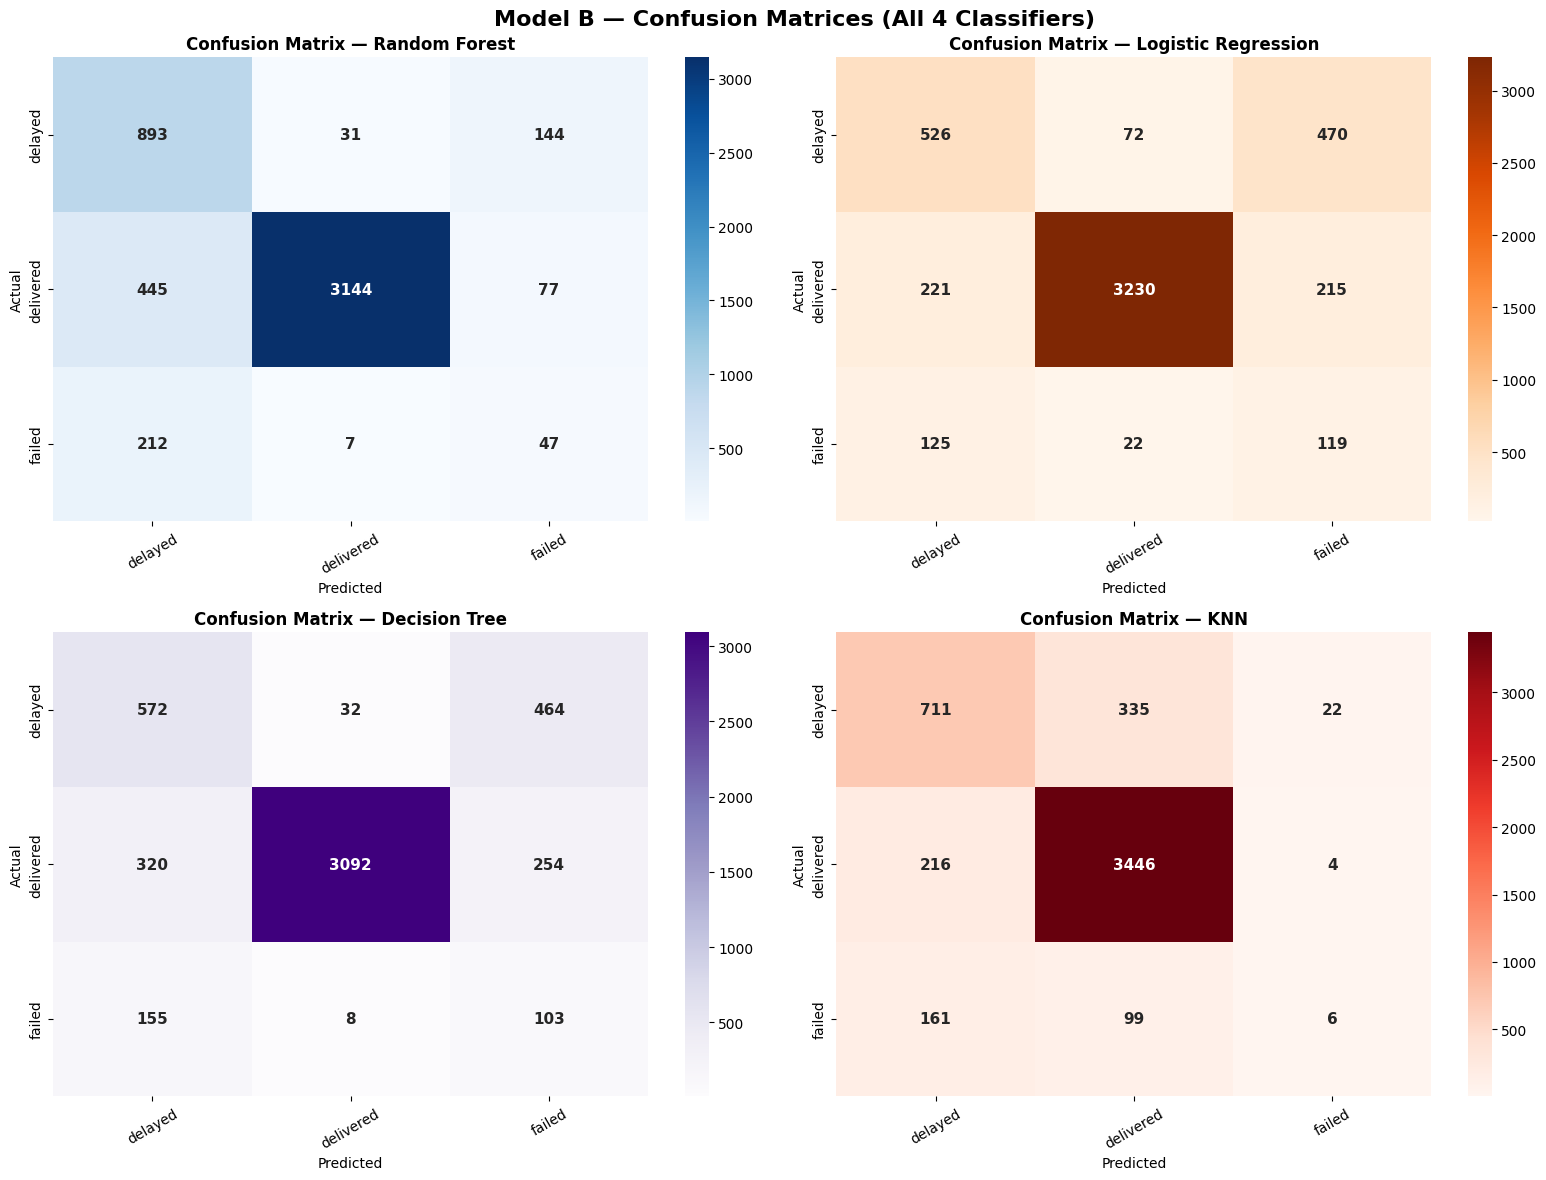

In [29]:
# ============================================================
# STEP 11 — CONFUSION MATRICES: ALL 4 MODELS (Model B)
# ============================================================

class_labels_B = sorted(y_B.unique())

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

models_B_info = [
    (y_pred_rf_B,  'Random Forest',       'Blues'),
    (y_pred_lr_B2, 'Logistic Regression', 'Oranges'),
    (y_pred_dt_B,  'Decision Tree',       'Purples'),
    (y_pred_knn_B, 'KNN',                 'Reds'),
]

for i, (y_pred, title, cmap) in enumerate(models_B_info):
    cm = confusion_matrix(y_test_B, y_pred, labels=class_labels_B)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[i],
                xticklabels=class_labels_B,
                yticklabels=class_labels_B,
                annot_kws={'size': 11, 'weight': 'bold'})
    axes[i].set_title(f'Confusion Matrix — {title}', fontweight='bold', fontsize=12)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Model B — Confusion Matrices (All 4 Classifiers)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


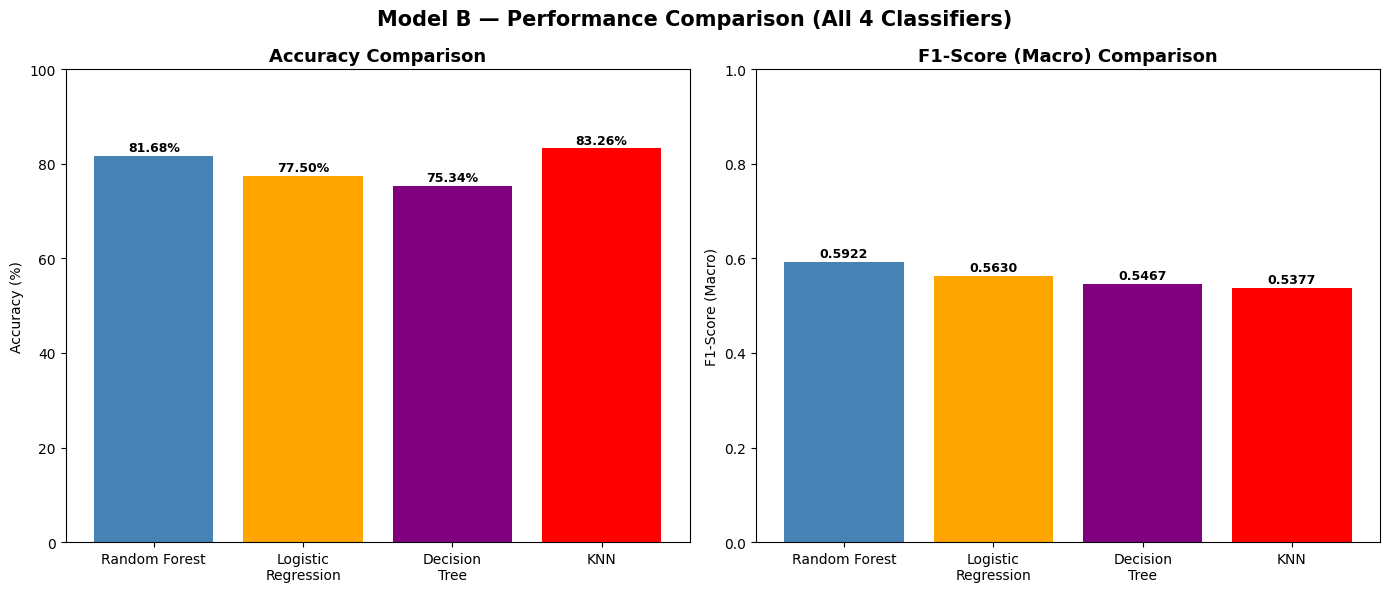

In [30]:
# ============================================================
# STEP 12 — ACCURACY & F1 BAR CHART (Model B)
# ============================================================

all_models_B     = ['Random Forest', 'Logistic\nRegression', 'Decision\nTree', 'KNN']
all_accuracies_B = [rf_acc_B*100, lr_acc_B2*100, dt_acc_B*100, knn_acc_B*100]
all_f1s_B        = [rf_f1_B, lr_f1_B2, dt_f1_B, knn_f1_B]
all_colors_B     = ['steelblue', 'orange', 'purple', 'red']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].bar(all_models_B, all_accuracies_B, color=all_colors_B)
axes[0].set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([0, 100])
for i, v in enumerate(all_accuracies_B):
    axes[0].text(i, v + 1, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=9)

axes[1].bar(all_models_B, all_f1s_B, color=all_colors_B)
axes[1].set_title('F1-Score (Macro) Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1-Score (Macro)')
axes[1].set_ylim([0, 1])
for i, v in enumerate(all_f1s_B):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Model B — Performance Comparison (All 4 Classifiers)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [31]:
# ============================================================
# STEP 13 — SUMMARY TABLE (Model B)
# ============================================================

summary_B = pd.DataFrame({
    'Model':        ['Random Forest', 'Logistic Regression', 'Decision Tree', 'KNN'],
    'Accuracy (%)': [f"{v:.2f}" for v in all_accuracies_B],
    'F1-macro':     [f"{v:.4f}" for v in all_f1s_B],
})

print("MODEL B — FINAL COMPARISON (All 4 Classifiers)")
print("=" * 55)
print(summary_B.to_string(index=False))

best_acc_idx_B = all_accuracies_B.index(max(all_accuracies_B))
best_f1_idx_B  = all_f1s_B.index(max(all_f1s_B))
print(f"Best by Accuracy : {summary_B['Model'][best_acc_idx_B]} ({max(all_accuracies_B):.2f}%)")
print(f" Best by F1-macro : {summary_B['Model'][best_f1_idx_B]} ({max(all_f1s_B):.4f})")


MODEL B — FINAL COMPARISON (All 4 Classifiers)
              Model Accuracy (%) F1-macro
      Random Forest        81.68   0.5922
Logistic Regression        77.50   0.5630
      Decision Tree        75.34   0.5467
                KNN        83.26   0.5377
Best by Accuracy : KNN (83.26%)
 Best by F1-macro : Random Forest (0.5922)


## SAVE ALL MODELS

In [32]:
import os

MODEL_PATH = "../models/"
os.makedirs(MODEL_PATH, exist_ok=True)

# Model A
with open(MODEL_PATH + 'rf_A_model.pkl', 'wb') as f: pickle.dump(rf_A, f)
with open(MODEL_PATH + 'lr_A_model.pkl', 'wb') as f: pickle.dump(lr_A2, f)
with open(MODEL_PATH + 'dt_A_model.pkl', 'wb') as f: pickle.dump(dt_A, f)
with open(MODEL_PATH + 'knn_A_model.pkl', 'wb') as f: pickle.dump(knn_A, f)

# Model B
with open(MODEL_PATH + 'rf_B_model.pkl', 'wb') as f: pickle.dump(rf_B, f)
with open(MODEL_PATH + 'lr_B_model.pkl', 'wb') as f: pickle.dump(lr_B2, f)
with open(MODEL_PATH + 'dt_B_model.pkl', 'wb') as f: pickle.dump(dt_B, f)
with open(MODEL_PATH + 'knn_B_model.pkl', 'wb') as f: pickle.dump(knn_B, f)

# Scalers & Encoders
with open(MODEL_PATH + 'scaler_A.pkl', 'wb') as f: pickle.dump(scaler_A, f)
with open(MODEL_PATH + 'scaler_B.pkl', 'wb') as f: pickle.dump(scaler_B, f)
with open(MODEL_PATH + 'encoders_A.pkl', 'wb') as f: pickle.dump(encoders_A, f)
with open(MODEL_PATH + 'encoders_B.pkl', 'wb') as f: pickle.dump(encoders_B, f)

print("✅ Models saved to project/models folder")

✅ Models saved to project/models folder


# Regression Model

In [33]:
# IMPORT 

import pandas as pd
import numpy as np
!pip install xgboost
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
y = df['delay_hours_recon']

# Drop unnecessary columns
# FIX: Added speed_kmph_recon and speed_category — actual speed is only known
# AFTER delivery completes, so it cannot be used to predict delay hours.
df_model = df.drop(columns=[
    'delivery_id',
    'delay_hours_recon',
    'delivery_time_hours_recon',
    'delayed_flag_recon',
    'delayed',
    'delivery_status',
    'order_date_recon',
    'order_ts_recon',
    'delivery_ts_recon',
    'expected_ts_recon',
    'speed_kmph_recon',
    'speed_category',
])

X = df_model.copy()


In [35]:
# Numeric columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categorical columns
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric Features:", numeric_features)
print("Categorical Features:", categorical_features)

Numeric Features: ['distance_km', 'package_weight_kg', 'delivery_rating', 'delivery_cost', 'expected_time_hours_recon', 'weather_mult_recon', 'partner_mult_recon', 'hour', 'order_dayofweek', 'order_month', 'order_year', 'order_hour', 'is_weekend', 'rush_hour_flag', 'night_delivery_flag', 'delayed_flag', 'severe_delay_flag', 'efficiency_score', 'cost_per_km', 'cost_per_kg', 'heavy_flag', 'partner_delay_rate', 'region_delay_rate', 'vehicle_delay_rate', 'mode_delay_rate', 'bad_weather_flag', 'weather_severity', 'weather_distance_risk', 'status_delivered_flag', 'load_index', 'cost_weather_risk', 'partner_weather_risk', 'time_ratio', 'early_flag', 'target']
Categorical Features: ['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'order_day_name', 'delay_severity']


In [36]:
# Preprocessing pipelines

numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# RandomForestRegressor

In [38]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

In [40]:
rf_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_param_grid,
    n_iter=15,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,n_iter,15
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [41]:
rf_best = rf_search.best_estimator_

y_pred_rf = rf_best.predict(X_test)

print("Random Forest Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))

Random Forest Results:
MAE: 0.003408753970436625
RMSE: 0.024672873660359078
R2: 0.9999980484243008


# XGBoostRegressor

In [42]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        random_state=42
    ))
])

In [43]:
xgb_param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    n_iter=15,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200, ...], ...}"
,n_iter,15
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [44]:
xgb_best = xgb_search.best_estimator_

y_pred_xgb = xgb_best.predict(X_test)

print("XGBoost Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R2:", r2_score(y_test, y_pred_xgb))

XGBoost Results:
MAE: 0.023359024447584455
RMSE: 0.03528830277125517
R2: 0.9999960078442743


In [45]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'R2 Score': [
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb)
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ]
})

print(results)

           Model  R2 Score       MAE      RMSE
0  Random Forest  0.999998  0.003409  0.024673
1        XGBoost  0.999996  0.023359  0.035288
